In [1]:
from utils_ml import *

In [2]:
# Load and concatenate all features
file_prefix = "dataExt/P"
file_suffix = "_intensity.pkl"
num_files = 35

old_label_arr = np.array([np.tile(i,np.load(f"{file_prefix}{0:02d}{file_suffix}", allow_pickle=True).shape[0]) for i in np.arange(num_files)]).flatten()

In [3]:
# Define the mapping from class labels (0 to 7) to the new 3-element array format
# where each element in the array represents the number of poles on [bt], [bb], and [tb]
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}



# Example usage:

new_label_arr = convert_labels(old_label_arr, class_to_poles)

print("Old Labels:\n", old_label_arr)
print("New Labels:\n", new_label_arr)

Old Labels:
 [ 0  0  0 ... 34 34 34]
New Labels:
 [[0 0 0]
 [0 0 0]
 [0 0 0]
 ...
 [1 1 2]
 [1 1 2]
 [1 1 2]]


In [4]:
features_memmap = np.load('dataExt/features_selected.npy', mmap_mode='r+')
gc.collect()
X_train, X_test, y_train, y_test = train_test_split(features_memmap, new_label_arr, test_size=0.1, random_state=42)

# Option 2: One model multi output

In [5]:
kfold = KFold(n_splits=2, shuffle=True, random_state=42)
kfold_models = []

for fold, (train_idx, val_idx) in enumerate(kfold.split(X_train)):
    
    rg = CatBoostRegressor(
      verbose=100,           
      random_state=fold,
      loss_function="MultiRMSE",
      iterations=1000,
      depth=8
      )
    
    rg.fit(X_train[train_idx], y_train[train_idx], eval_set=(X_train[val_idx],y_train[val_idx]), plot=True)
    kfold_models.append(rg)
    rg.save_model(f"saved_models/model_fold_rg_multirmse_35_{fold}")
    break

MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 1.8596967	test: 1.8587755	best: 1.8587755 (0)	total: 267ms	remaining: 4m 27s
100:	learn: 0.8474355	test: 0.8498348	best: 0.8498348 (100)	total: 18.3s	remaining: 2m 43s
200:	learn: 0.7706382	test: 0.7737597	best: 0.7737597 (200)	total: 35.5s	remaining: 2m 21s
300:	learn: 0.7388460	test: 0.7426628	best: 0.7426628 (300)	total: 52.9s	remaining: 2m 2s
400:	learn: 0.7193185	test: 0.7239055	best: 0.7239055 (400)	total: 1m 11s	remaining: 1m 46s
500:	learn: 0.7044927	test: 0.7100024	best: 0.7100024 (500)	total: 1m 30s	remaining: 1m 29s
600:	learn: 0.6930993	test: 0.6996750	best: 0.6996750 (600)	total: 1m 49s	remaining: 1m 12s
700:	learn: 0.6840862	test: 0.6915997	best: 0.6915997 (700)	total: 2m 7s	remaining: 54.5s
800:	learn: 0.6765633	test: 0.6849566	best: 0.6849566 (800)	total: 2m 27s	remaining: 36.6s
900:	learn: 0.6703930	test: 0.6797733	best: 0.6797733 (900)	total: 2m 46s	remaining: 18.3s
999:	learn: 0.6650810	test: 0.6754926	best: 0.6754926 (999)	total: 3m 7s	remaining: 0us

best

In [6]:
acc_arr = []
for cnt, submodel in enumerate(kfold_models):
    _pred = submodel.predict(X_test)
    acc_arr.extend([np.sum(np.sum(np.round(_pred)==y_test,axis=1) == 3)/np.sum(np.ones_like(y_test[:,0]))])
print(f"Test Accuracy = {np.mean(acc_arr):.4f} +/- {np.std(acc_arr):.3f}")

Test Accuracy = 0.5394 +/- 0.000


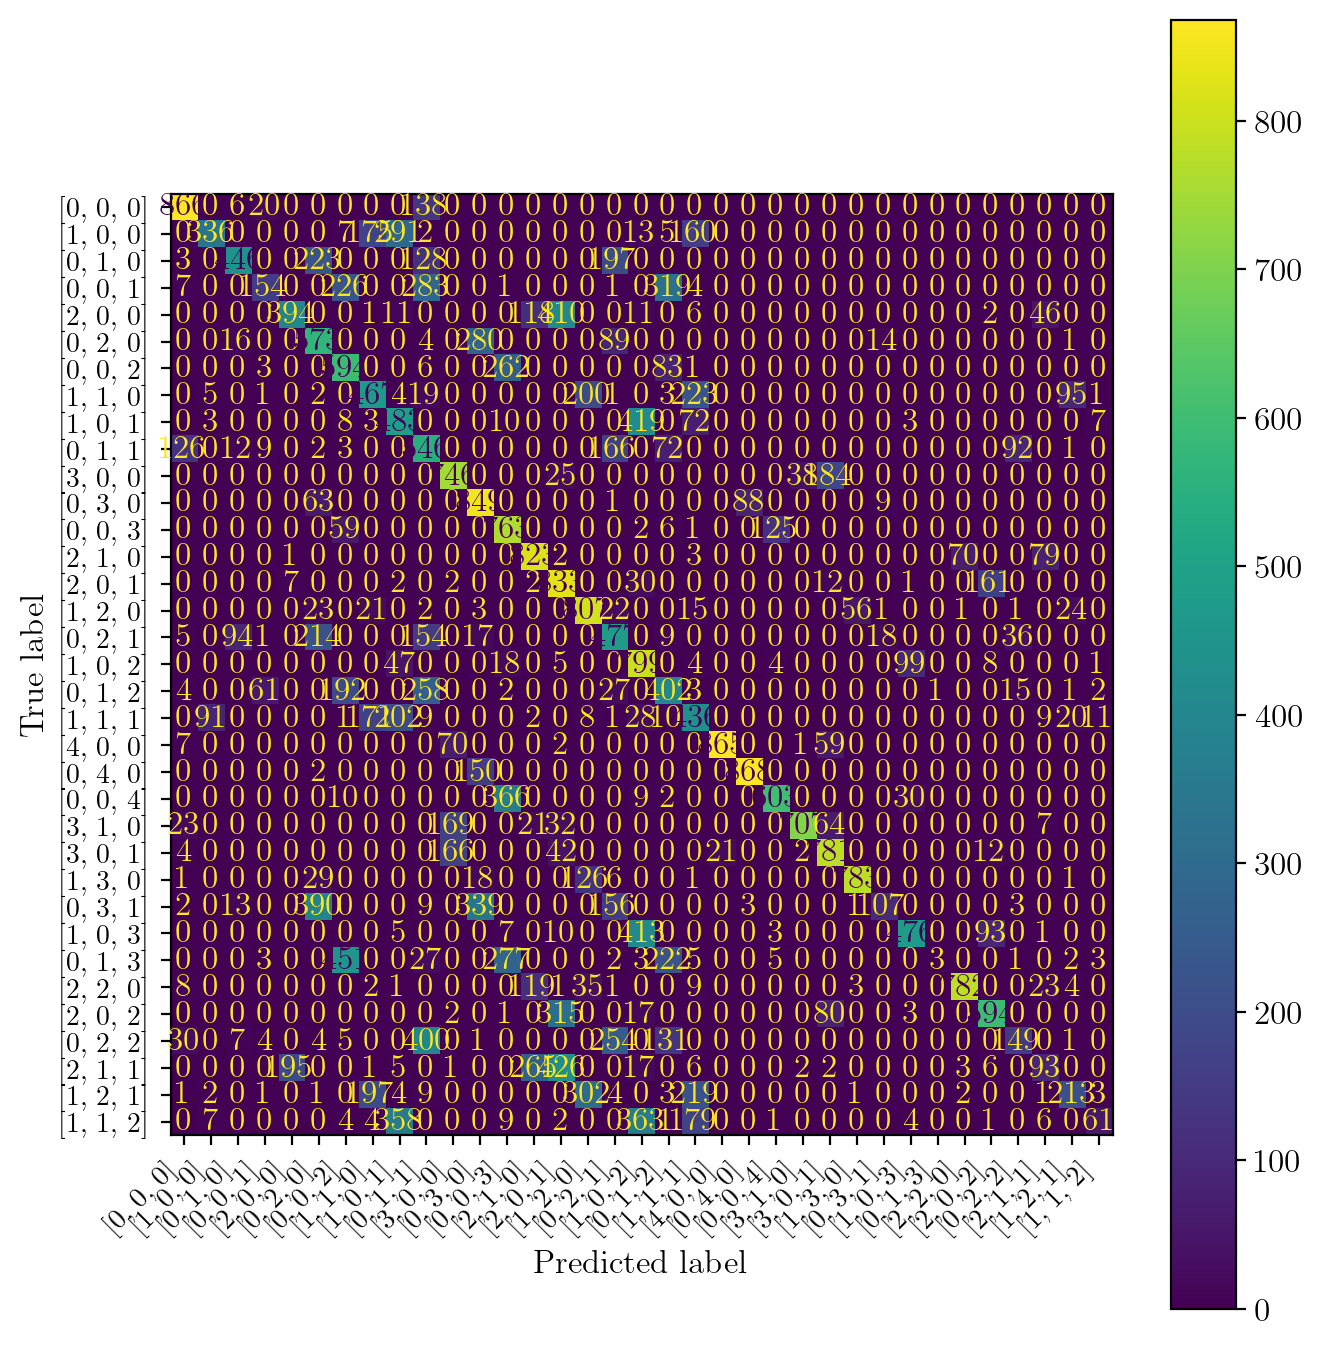

In [ ]:
# Custom labels for the axes
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Aggregate predictions over the folds
mean_predictions = [] #np.zeros((len(X_test), len(class_to_poles)))
for model in kfold_models:
    _preds = model.predict(X_test)
    predictions = reconvert_labels(np.abs(np.round(_preds)).tolist(), class_to_poles)
    mean_predictions.append(predictions)

mean_predictions = np.round(np.array(mean_predictions).mean(axis=0))
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Compute the confusion matrix
cm = confusion_matrix(reconvert_labels(y_test, class_to_poles), mean_predictions, labels=np.arange(len(class_to_poles)))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(7, 7))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()

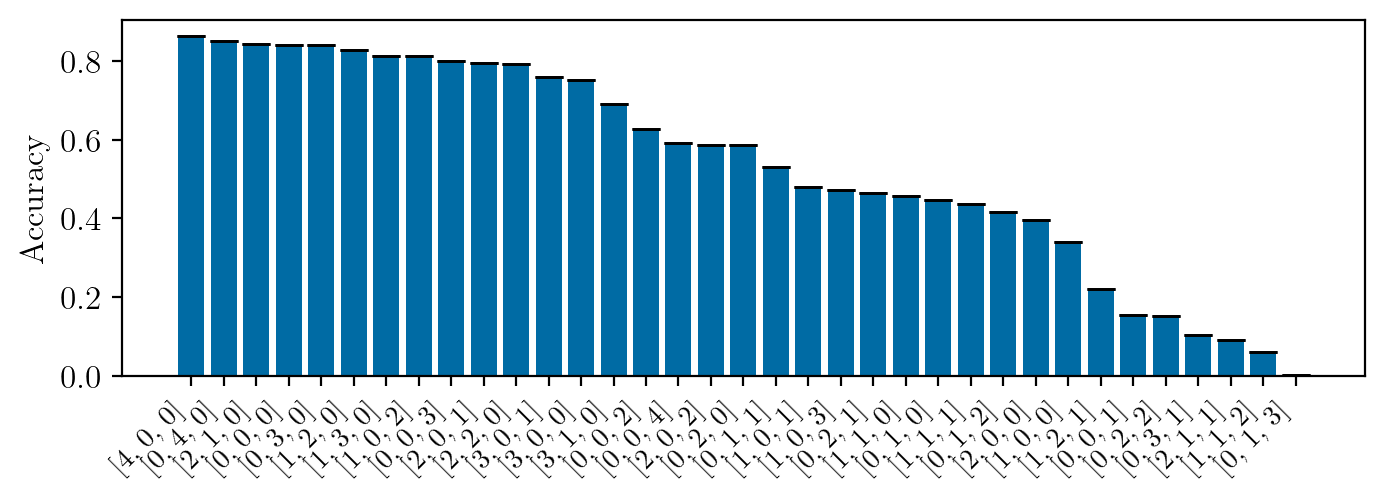

In [11]:
# Number of classes
num_classes = 35

# Initialize an array to store accuracies for each class across folds
class_accuracies_folds = np.zeros((len(kfold_models), num_classes))

# Calculate per-class accuracy for each fold
for fold_idx, model in enumerate(kfold_models):
    fold_accuracies = []
    for cls in range(num_classes):
        # Mask for the current class
        
        class_mask = (reconvert_labels(y_test, class_to_poles) == cls)
        # Calculate accuracy for the current fold and class
        # /np.sum(np.ones_like(y_test[:,0]))
        class_accuracy = np.sum(np.sum(np.round(_pred[class_mask])==y_test[class_mask],axis=1) == 3) / np.sum(class_mask)
        fold_accuracies.append(class_accuracy)
    class_accuracies_folds[fold_idx] = fold_accuracies

# Compute mean and standard deviation of accuracies across folds
class_accuracies_mean = class_accuracies_folds.mean(axis=0)
class_accuracies_std = class_accuracies_folds.std(axis=0)

# Bar plot with error bars
sorted_indices = np.argsort(class_accuracies_mean)[::-1]
sorted_means = class_accuracies_mean[sorted_indices]
sorted_stds = class_accuracies_std[sorted_indices]
sorted_labels = [str(class_to_poles[i]) for i in sorted_indices]

# Plotting
fig, ax = plt.subplots(figsize=(3.54331*2, 3.54331*0.75))
ax.bar(range(num_classes), sorted_means, yerr=sorted_stds, capsize=5)
ax.set_ylabel('Accuracy')

ax.set_xticks(np.arange(len(sorted_labels)))
ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=10)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

In [ ]:
class_to_poles = {
    0: [0, 0, 0],  # 1 pole on [bt]
    1: [1, 0, 0],  # 1 pole on [bb]
    2: [0, 1, 0],  # 1 pole on [tb]
    3: [0, 0, 1],  # 1 pole on [bt] and 1 pole on [bb]
    4: [2, 0, 0],  # 1 pole on [bb] and 1 pole on [tb]
    5: [0, 2, 0],  # 1 pole on each of [bt], [bb], and [tb]
    6: [0, 0, 2],  # 2 poles on [bb] and 1 pole on [tb]
    7: [1, 1, 0],   # 1 pole on [bb] and 2 poles on [tb]
    8: [1, 0, 1],
    9: [0, 1, 1],
    10: [3, 0, 0],
    11: [0, 3, 0],
    12: [0, 0, 3],
    13: [2, 1, 0],
    14: [2, 0, 1],
    15: [1, 2, 0],
    16: [0, 2, 1],
    17: [1, 0, 2],
    18: [0, 1, 2],
    19: [1, 1, 1],
    20: [4, 0, 0],
    21: [0, 4, 0],
    22: [0, 0, 4],
    23: [3, 1, 0],
    24: [3, 0, 1],
    25: [1, 3, 0],
    26: [0, 3, 1],
    27: [1, 0, 3],
    28: [0, 1, 3],
    29: [2, 2, 0],
    30: [2, 0, 2],
    31: [0, 2, 2],
    32: [2, 1, 1],
    33: [1, 2, 1],
    34: [1, 1, 2],
}

# Custom labels for the axes
custom_labels = [str(class_to_poles[i]) for i in range(len(class_to_poles))]

# Aggregate predictions over the folds
mean_predictions = np.zeros((len(X_test), len(class_to_poles)))
for model in kfold_models:
    fold_probs = model.predict_proba(X_test)  # Get probabilities for all classes
    mean_predictions += fold_probs
mean_predictions /= len(kfold_models)  # Average predictions across folds

# Get the final predicted class based on mean probabilities
final_predictions = np.argmax(mean_predictions, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, final_predictions, labels=np.arange(len(class_to_poles)))

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.arange(len(class_to_poles)))
fig, ax = plt.subplots(figsize=(7, 7))  # Adjust figure size if needed
disp.plot(ax=ax)

# Update x and y axis tick labels with the custom labels
ax.set_xticks(np.arange(len(custom_labels)))
ax.set_yticks(np.arange(len(custom_labels)))
ax.set_xticklabels(custom_labels, rotation=45, ha='right', fontsize=10)
ax.set_yticklabels(custom_labels, fontsize=10)

# Adjust layout for readability
plt.tight_layout()
plt.show()
